# Regression: II

*Davide Gerosa (Milano-Bicocca)* 

##### Reading:

- [Textbook](http://press.princeton.edu/titles/10159.html) Chapter 8.

##### More

- *[Rasmussen and Williams "Gaussian Processes for Machine Learning" (2005)](http://www.gaussianprocess.org/gpml/)*

This course is based on previous work by many people. See [here]((https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/README.md) for credits.


---

## Regularization <a class="anchor" id="one"></a>

We have to be careful when performing regression because if we progressively increase the complexity of the model, then we reach a regime where we are overfitting the data (i.e. there are too many degrees of freedom in the model). This causes high variance in the model, resulting in poor performance in cross-validation and testing datasets.

Let's look at an example using `Polynomial Regression`. We'll fit some data with successively higher-degree polynomials.

In [21]:
# Execute this cell
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

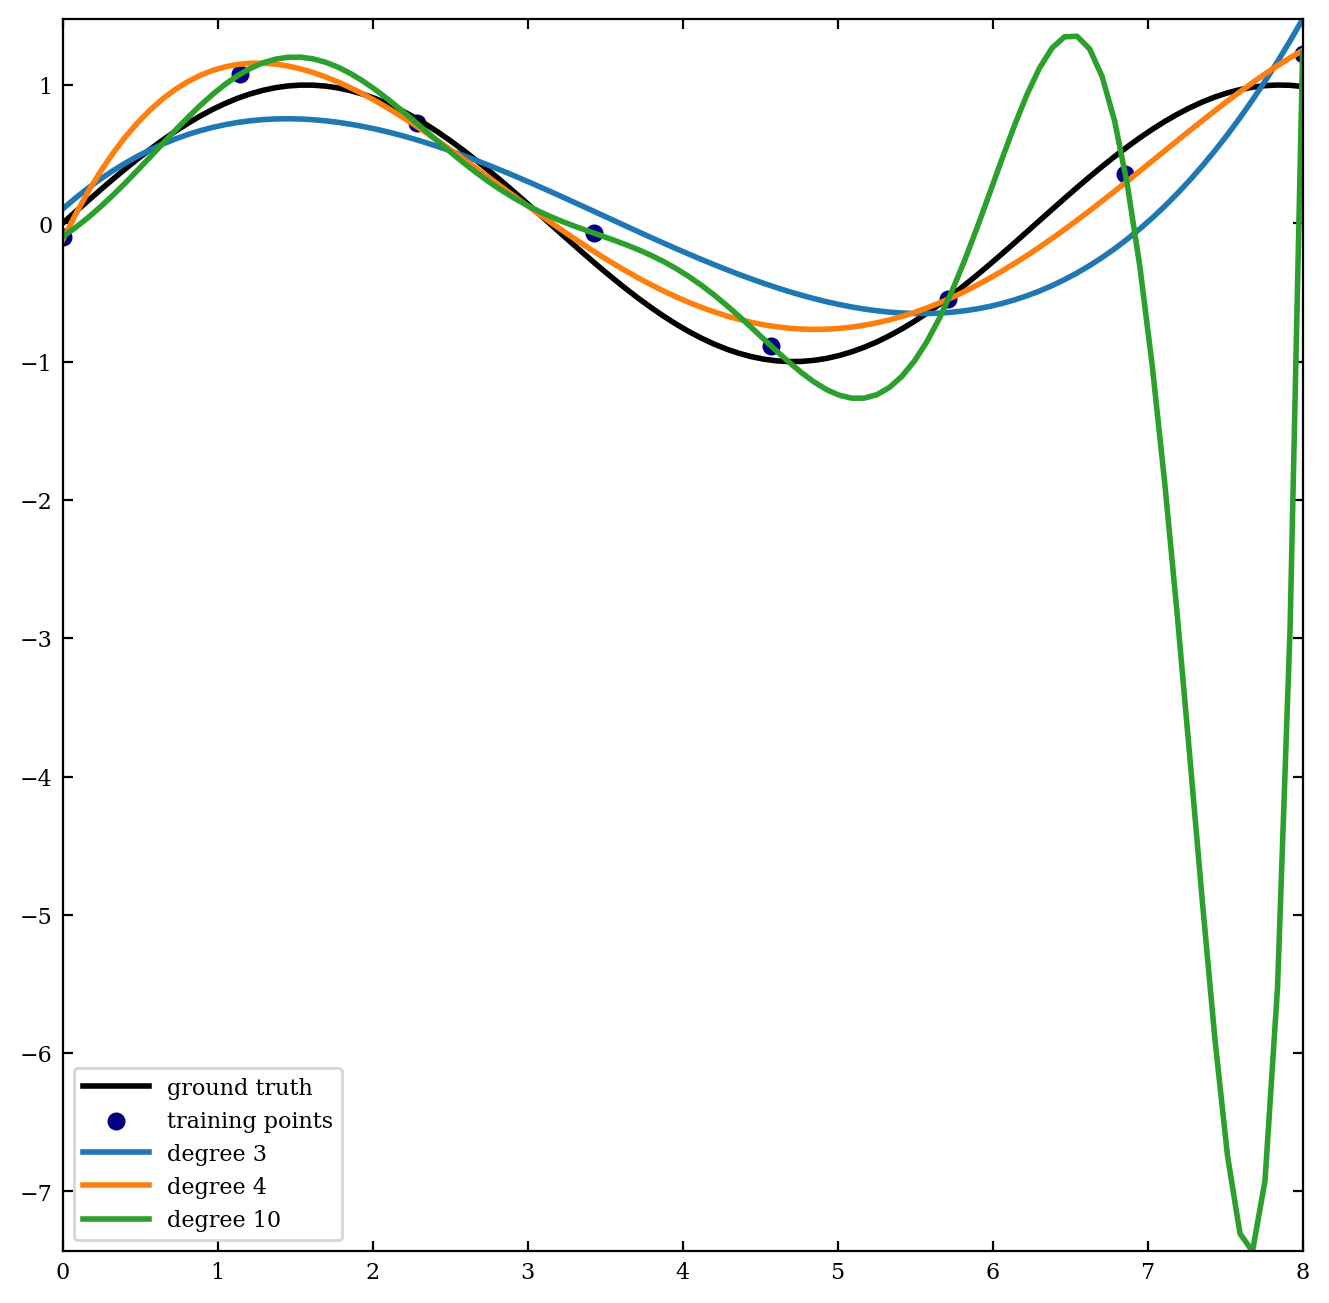

In [22]:
from astroML.linear_model import PolynomialRegression

degrees = [3,4,10]

def f(x):
    """ function to approximate by polynomial interpolation """
    return np.sin(x)

# generate points used to plot
x_plot = np.linspace(0, 8, 100)

# generate points and keep a subset of them
x = np.linspace(0, 8, 8)
y = f(x) + 0.5 * (np.random.random(len(x)) - 0.5)

# create matrix versions of these arrays
X = x[:, None]
X_plot = x_plot[:, None]

colors = ['C0', 'C1', 'C2']
lw = 2
plt.figure(figsize=(8,8))
plt.plot(x_plot, f(x_plot), 
         color='black', 
         linewidth=lw, label="ground truth")
plt.scatter(x, y, color='navy', s=30, 
            marker='o', label="training points")

for count, degree in enumerate(degrees):
    poly = PolynomialRegression(degree)
    poly.fit(X,y)
    y_plot = poly.predict(X_plot)

    plt.plot(x_plot, y_plot, color=colors[count], 
             linewidth=lw, label="degree %d" % degree)

plt.legend(loc='lower left')

plt.show();

What happens if you make the degree is equal to $\sim N_{\rm points}$ and higher?

In that case we are clearly overfitting the data. For me it was visible in the space between the penultimate and final data point, where the model had huge variance and would have performed terribly in cross-validation.

For cases where we are concerned with overfitting, instead of making our log-likelihood be related to just the sum of the squares: 

$$(Y - M\theta)^T C^{-1} (Y - M\theta),$$

we can apply additional constraints (usually of **smoothness**, **number of coefficients**, **size of coefficients**):

$$(Y - M \theta)^T C^{-1} (Y- M \theta) + \lambda\, \theta^T\theta,$$

with **$\lambda$ as the "regularization parameter"**. (NOTE: *This corrects and clarifies some of the math notation in Ivezic 8.3.*)

Upon maximizing the modified log-likelihood (or minimizing the modified relationship in the previous equation), this leads to a solution for the parameters of the model

$$\hat\theta = (M^T C^{-1} M + \lambda I)^{-1} (M^T C^{-1} Y)$$

with $I$ the identity matrix.

From the **Bayesian perspective** this is trivial. We have just applied a prior constraint on the parameters of our model that help control the posterior distribution of parameters. In this scenario, our prior is

$$p(\theta | I ) \propto \exp{\left(\frac{-\lambda\, \theta^T\theta}{2}\right)}$$

which, when multiplied by the data likelihood for regression, gives the same answer for the maximum of the posterior probability as described above.

***Reguarlization tries to get us into the regime where we have a [balanced solution](https://towardsdatascience.com/ridge-regression-for-better-usage-2f19b3a202db) to the regression between underfitting and overfitting***.
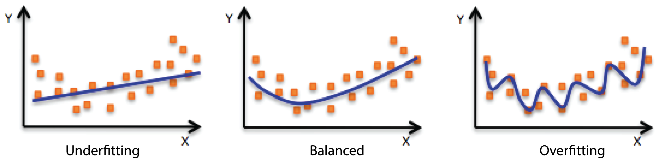

### Ridge regression 

Such a Gaussian prior on regression coefficients corresponds to **[Ridge Regression](https://en.wikipedia.org/wiki/Tikhonov_regularization)** (or ***Tikhonov Regularization***), which penalizes the regression coefficients according to

$$ \theta^T \theta \equiv \sum_i \theta_i^2 < s.$$

That is **the sum of the squares of the regression coefficients are restricted to be less than some tolerance value**, $s$, which will need to be tuned. Doing this supresses large regression coefficients and limits the variance of the model---at the cost of increased bias (i.e. the solution may not pass as closely through all data points).

In [23]:
from sklearn.linear_model import Ridge

X = np.random.random((100,10))
y = np.dot(X, np.random.random(10))
model = Ridge(alpha=0.05) # alpha here is lambda in the book
model.fit(X,y)
y_pred = model.predict(X)

Let's use the supernova data from last time.

The following example compares *Gaussian Basis Regression* with and without the constraints from *Ridge Regression*. It uses **$100$ evenly spaced Gauassians, which we can see strongly overfits the problem and has very large coefficient values, until a constraint is imposed**.

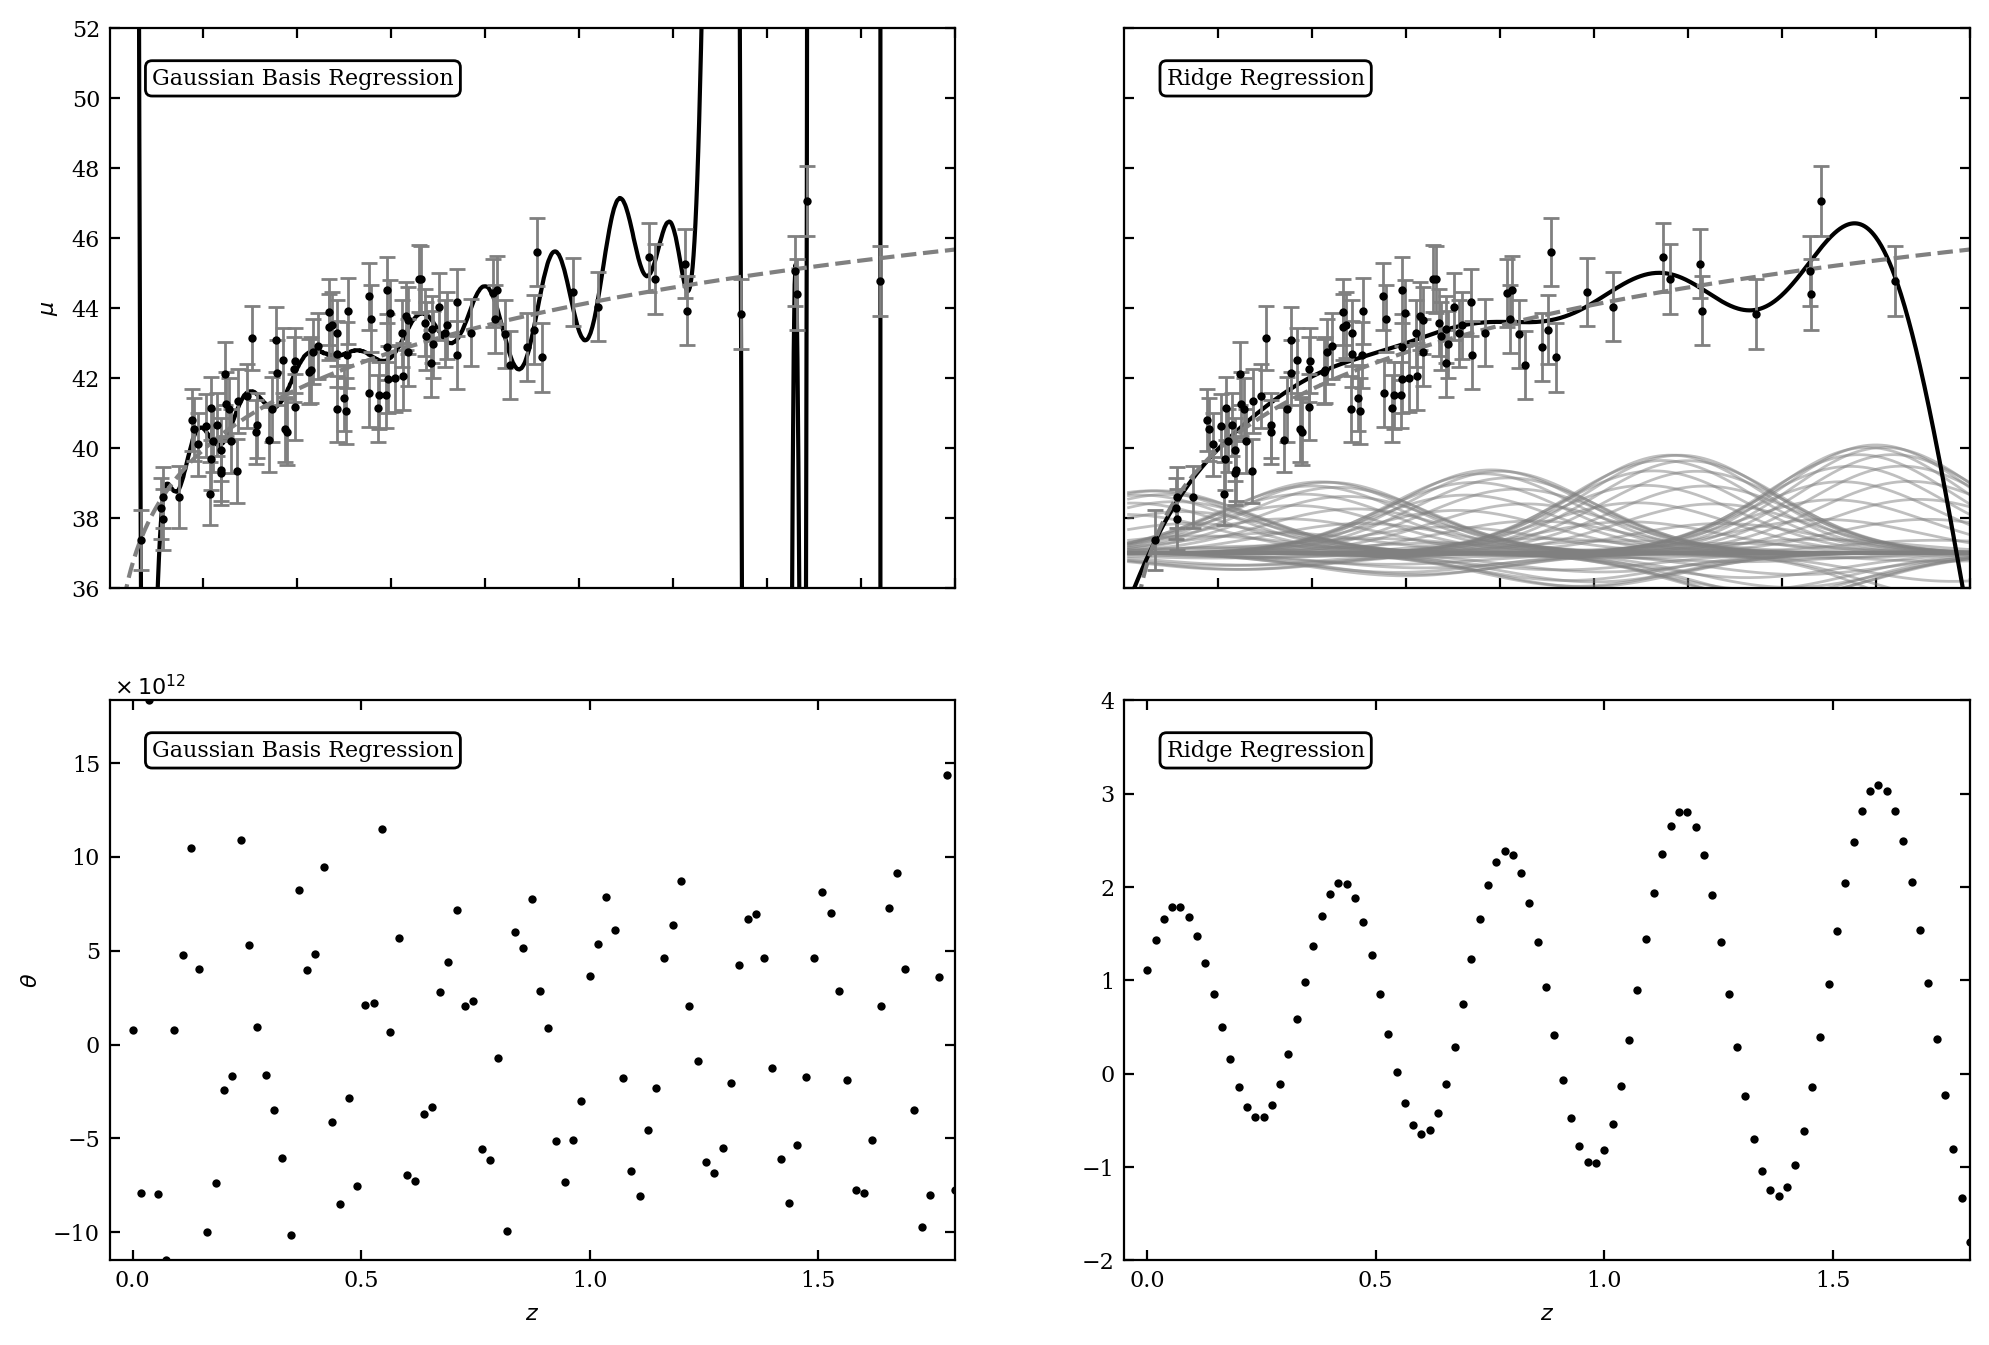

In [24]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from scipy.stats import lognorm
from sklearn.linear_model import LinearRegression, Ridge
from astroML.datasets import generate_mu_z

#----------------------------------------------------------------------
# generate data
np.random.seed(0)
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=0)

from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=70, Om0=0.30, Ode0=0.70, Tcmb0=0)
z = np.linspace(0.01, 2, 1000)
mu = cosmo.distmod(z)

#------------------------------------------------------------
# Manually convert data to a gaussian basis
#  note that we're ignoring errors here, for the sake of example.
def gaussian_basis(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

centers = np.linspace(0, 1.8, 100)
widths = 0.2
X = gaussian_basis(z_sample[:, None], 
                   centers, widths)

#------------------------------------------------------------
# Set up the figure to plot the results
fig = plt.figure(figsize=(12, 8))

classifier = [LinearRegression, Ridge]
kwargs = [dict(), dict(alpha=0.005)]
labels = ['Gaussian Basis Regression', 'Ridge Regression']

for i in range(2):
    clf = classifier[i](fit_intercept=True, **kwargs[i])
    clf.fit(X, mu_sample)
    w = clf.coef_
    fit = clf.predict(gaussian_basis(z[:, None], 
                                     centers, widths))

    # plot fit
    ax = fig.add_subplot(221 + i)
    ax.xaxis.set_major_formatter(plt.NullFormatter())

    # plot curves for regularized fits
    if i == 0:
        ax.set_ylabel('$\mu$')
    else:
        ax.yaxis.set_major_formatter(plt.NullFormatter())
        curves = 37 + w * gaussian_basis(z[:, np.newaxis], 
                                         centers, widths)
        curves = curves[:, abs(w) > 0.01]
        ax.plot(z, curves,
                c='gray', lw=1, alpha=0.5)

    ax.plot(z, fit, '-k')
    ax.plot(z, mu, '--', c='gray')
    ax.errorbar(z_sample, mu_sample, dmu, 
                fmt='.k', ecolor='gray', lw=1, ms=4)
    ax.set_xlim(0.001, 1.8)
    ax.set_ylim(36, 52)
    ax.text(0.05, 0.93, labels[i],
            ha='left', va='top',
            bbox=dict(boxstyle='round', 
                      ec='k', fc='w'),
            transform=ax.transAxes)

    # plot weights
    ax = plt.subplot(223 + i)
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax.set_xlabel('$z$')
    if i == 0:
        ax.set_ylabel(r'$\theta$')
        w *= 1E-12
        ax.text(0, 1.01, r'$\rm \times 10^{12}$',
                transform=ax.transAxes)
    ax.scatter(centers, w, s=9, lw=0, c='k')

    ax.set_xlim(-0.05, 1.8)

    if i == 1:
        ax.set_ylim(-2, 4)
    elif i == 2:
        ax.set_ylim(-0.5, 2)

    ax.text(0.05, 0.93, labels[i],
            ha='left', va='top',
            bbox=dict(boxstyle='round', 
                      ec='k', fc='w'),
            transform=ax.transAxes)

plt.show()

### Least Absolute Shrinkage and Selection (LASSO) regularization

An alternative to Ridge Regression is **LASSO**, which implies the following contraint:

$$(Y - M \theta)^T(Y- M \theta) + \lambda \sum_i|\theta_i|.$$

This is equivalent to least-squares minimization with the restriction that

$$ \sum_i|\theta_i| < s,$$

that is, the **penalty is now on the sum of the absolute values of the regression coefficients**, which is also illustrated in Ivezic, Figure 8.3 as shown in the right panel above.

It not only weights the regression coefficients, it also imposes sparsity on the regression
model (i.e. the penalty preferentially selects regions of likelihood space that coincide with one of the vertices within the region defined by the regularization).

***This has the net effect of setting one (or more) of the model attributes to zero.***  


In [25]:
from sklearn.linear_model import Lasso

XX = np.random.random((100,10))
yy = np.dot(XX, np.random.random(10))
model = Lasso(alpha = 0.05)
model.fit(XX,yy)
y_pred = model.predict(XX)

Below I have copied the Ridge regression cell from above.

**N.B.  $\lambda$ in the book is related to $\alpha$ in these examples.**

/Users/dgerosa/box/lib/python3.11/site-packages/sklearn/base.py:1151: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/Users/dgerosa/box/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/Users/dgerosa/box/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.598e+01, tolerance: 3.196e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast

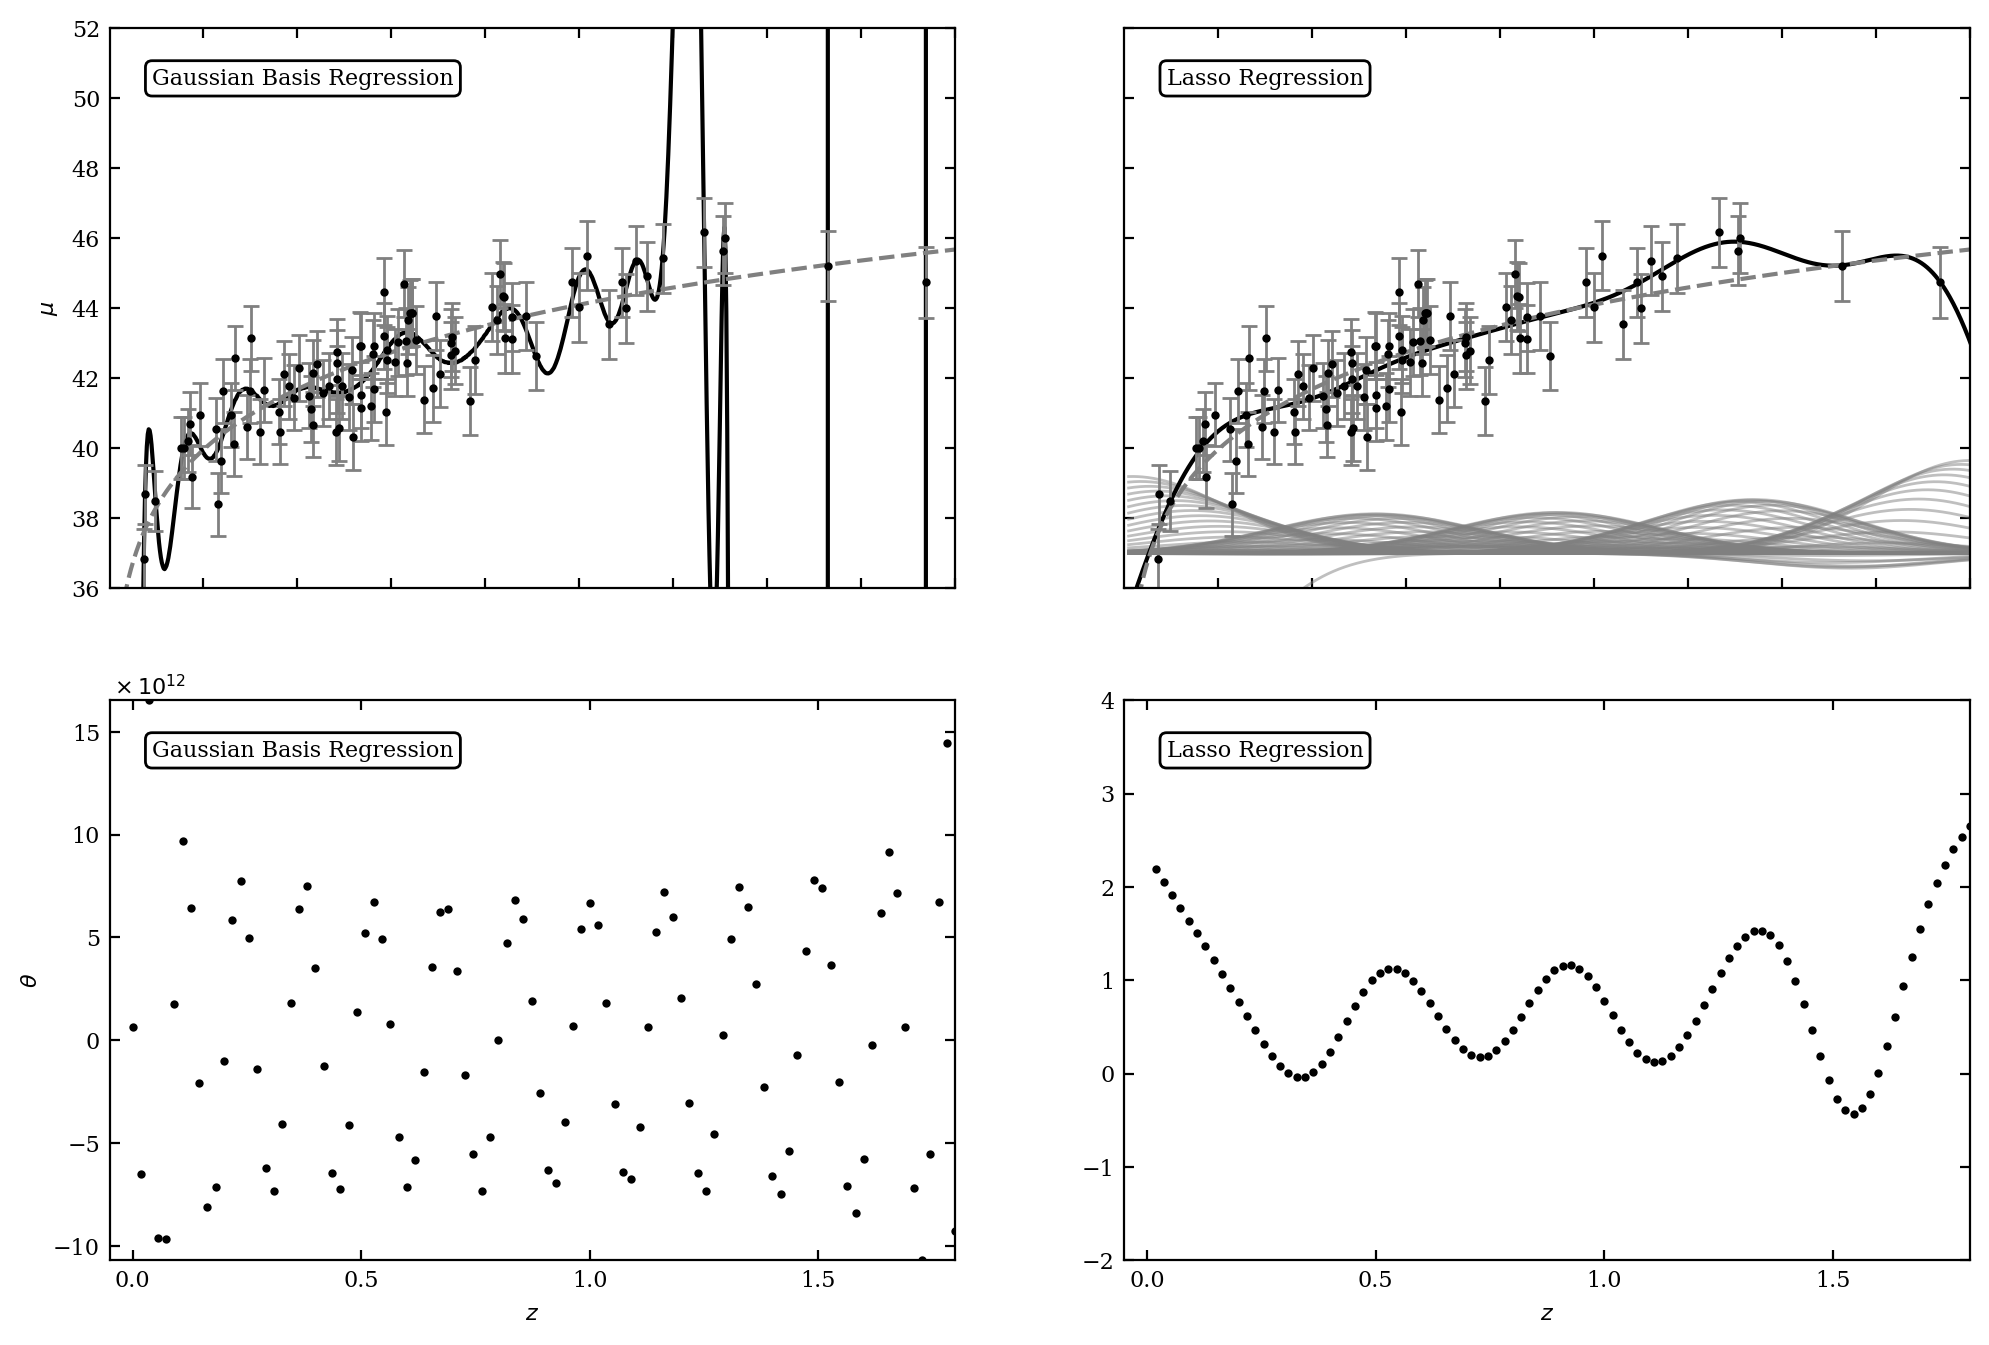

In [26]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from scipy.stats import lognorm
from sklearn.linear_model import LinearRegression, Lasso #!!!!

#from astroML.cosmology import Cosmology
from astroML.datasets import generate_mu_z

#----------------------------------------------------------------------
# generate data
np.random.seed(0)
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=70, Om0=0.30, Ode0=0.70, Tcmb0=0)
z = np.linspace(0.01, 2, 1000)
mu = cosmo.distmod(z)

#------------------------------------------------------------
# Manually convert data to a gaussian basis
#  note that we're ignoring errors here, for the sake of example.
def gaussian_basis(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

centers = np.linspace(0, 1.8, 100)
widths = 0.2
X = gaussian_basis(z_sample[:, None], centers, widths)

#------------------------------------------------------------
# Set up the figure to plot the results
fig = plt.figure(figsize=(12, 8))

classifier = [LinearRegression, Lasso] #!!!!
kwargs = [dict(), dict(alpha=int(0))]
labels = ['Gaussian Basis Regression', 'Lasso Regression'] #!!!!

for i in range(2):
    clf = classifier[i](fit_intercept=True, **kwargs[i])
    clf.fit(X, mu_sample)
    w = clf.coef_
    fit = clf.predict(gaussian_basis(z[:, None], centers, widths))

    # plot fit
    ax = fig.add_subplot(221 + i)
    ax.xaxis.set_major_formatter(plt.NullFormatter())

    # plot curves for regularized fits
    if i == 0:
        ax.set_ylabel('$\mu$')
    else:
        ax.yaxis.set_major_formatter(plt.NullFormatter())
        curves = 37 + w * gaussian_basis(z[:, np.newaxis], centers, widths)
        curves = curves[:, abs(w) > 0.01]
        ax.plot(z, curves,
                c='gray', lw=1, alpha=0.5)

    ax.plot(z, fit, '-k')
    ax.plot(z, mu, '--', c='gray')
    ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, ms=4)
    ax.set_xlim(0.001, 1.8)
    ax.set_ylim(36, 52)
    ax.text(0.05, 0.93, labels[i],
            ha='left', va='top',
            bbox=dict(boxstyle='round', ec='k', fc='w'),
            transform=ax.transAxes)

    # plot weights
    ax = plt.subplot(223 + i)
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax.set_xlabel('$z$')
    if i == 0:
        ax.set_ylabel(r'$\theta$')
        w *= 1E-12
        ax.text(0, 1.01, r'$\rm \times 10^{12}$',
                transform=ax.transAxes)
    ax.scatter(centers, w, s=9, lw=0, c='k')

    ax.set_xlim(-0.05, 1.8)

    if i == 1:
        ax.set_ylim(-2, 4)
    elif i == 2:
        ax.set_ylim(-0.5, 2)

    ax.text(0.05, 0.93, labels[i],
            ha='left', va='top',
            bbox=dict(boxstyle='round', ec='k', fc='w'),
            transform=ax.transAxes)

plt.show()

Among the many Gaussians we put in, the algorithm is selecting only a few. The cause of overfitting was precisely that we initialized too many Gaussians. The nice thing about regularization is that we don't have to manually decide which features are more or less important, this choice is made in a data-driven way.

On regularization, I found the relevant chapter in [Hastie et al.](https://link.springer.com/book/10.1007/978-0-387-84858-7) particularly clear. They write the constraint term as 

$$\lambda \sum_{i=1} |\theta_i|^q,$$

which allows us to see that **Ridge regression corresponds to $q=2$**, while **LASSO regression corresponds to $q=1$**.  So, they are really the same thing: Bayesian estimates with different priors. The wildly different names are just a nuisance. Hastie et al. shows what contours of the constant constraint term look like for different $q$.

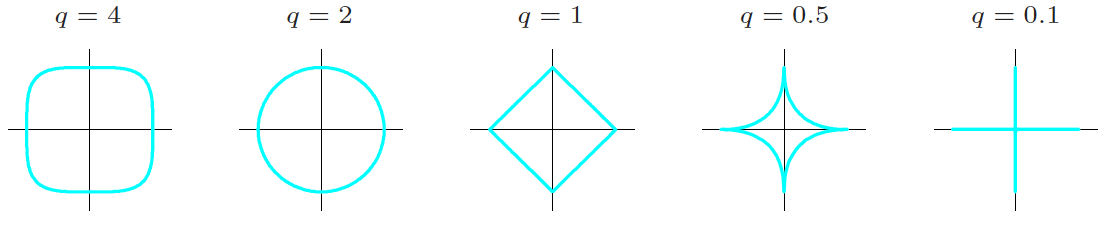

With that in mind, we now have

$$ \lambda \sum_{i=1} |\theta_i|^q < s.$$

Think of $s$ as a normalized distance where $s=1$ corresponds to there being no constraint on $\theta_i$. Requiring $s<1$ limits the magnitude of $\theta_i$. So, in Ivezic Figure 8.3
![Ivezic, Figure 8.3](http://www.astroml.org/_images/fig_lasso_ridge_1.png)
$s=1$ would make the circle/diamond big enough to include what they call $\theta_{\rm normal}$.   

Shrinking $s$ has the effect of adding a prior that moves the best-fit parameters to the intersection of the two sets of contours. **The difference between Ridge and LASSO is just the shape of the constraint region.** For LASSO, the shape is such that some of the parameters may end up being 0, which is super beneficial.

One drawback of LASSO is that it does not have a closed-form analytic regression like Ridge does-- the problem must be solved numerically.

#### Note (this once drove me crazy for a whole day!)

Setting $\lambda=0$ is mathemathicall identical to no regularizaion. But that's not necessarily true in the scikit-learn implementation: i.e. `Ridge` and `Lasso` with `alpha=0` might not give the same result of `LinearRegression`. The regularization algorithms have additional sophistications to improve convergence. I was not able to fully understand this (let me know if you do!) even after many hours of googling.

### Elastic Net and deep learning

Regularization is **vital** in deep learning. Deep learning models have $10^{\rm many}$ parameters and can very easily lead to overfitting.

One of the latest developing in deep learning is the so-called Elastic Net strategy which, simply put, combines Ridge and Lasso regularization. Elastic Net was first proposed in by [Zou and Hastie (2005)](https://rss.onlinelibrary.wiley.com/doi/10.1111/j.1467-9868.2005.00503.x). For a recent application to LSST forecasted data see [Weaverdyck and Huterer (2020)](https://arxiv.org/abs/2007.14499).





### How do we choose $\lambda$?

We use cross-validation, just as we discussed last time. In fact...`Scikit-Learn` has versions of Ridge and LASSO regression that do this automatically for you-- see [`RidgeCV`](https://scikit-learn.org/stable/modules/linear_model.html#setting-the-regularization-parameter-leave-one-out-cross-validation) and [`LassoCV`](https://scikit-learn.org/stable/modules/linear_model.html#using-cross-validation).

---

Let's practice all this using the [California Housing data](https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html).  

As a reminder, this data set contains 8 attributes that can be used to predict the price of houses in California.  Because the attributes (columns of $X$) are inhomogenous, some may be more relevant than others. So LASSO might be a good thing to try in such situations.

In [27]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [28]:
housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

The target is the median value of the houses in the area, in units of hundreds of thousands of dollars ($100,000)

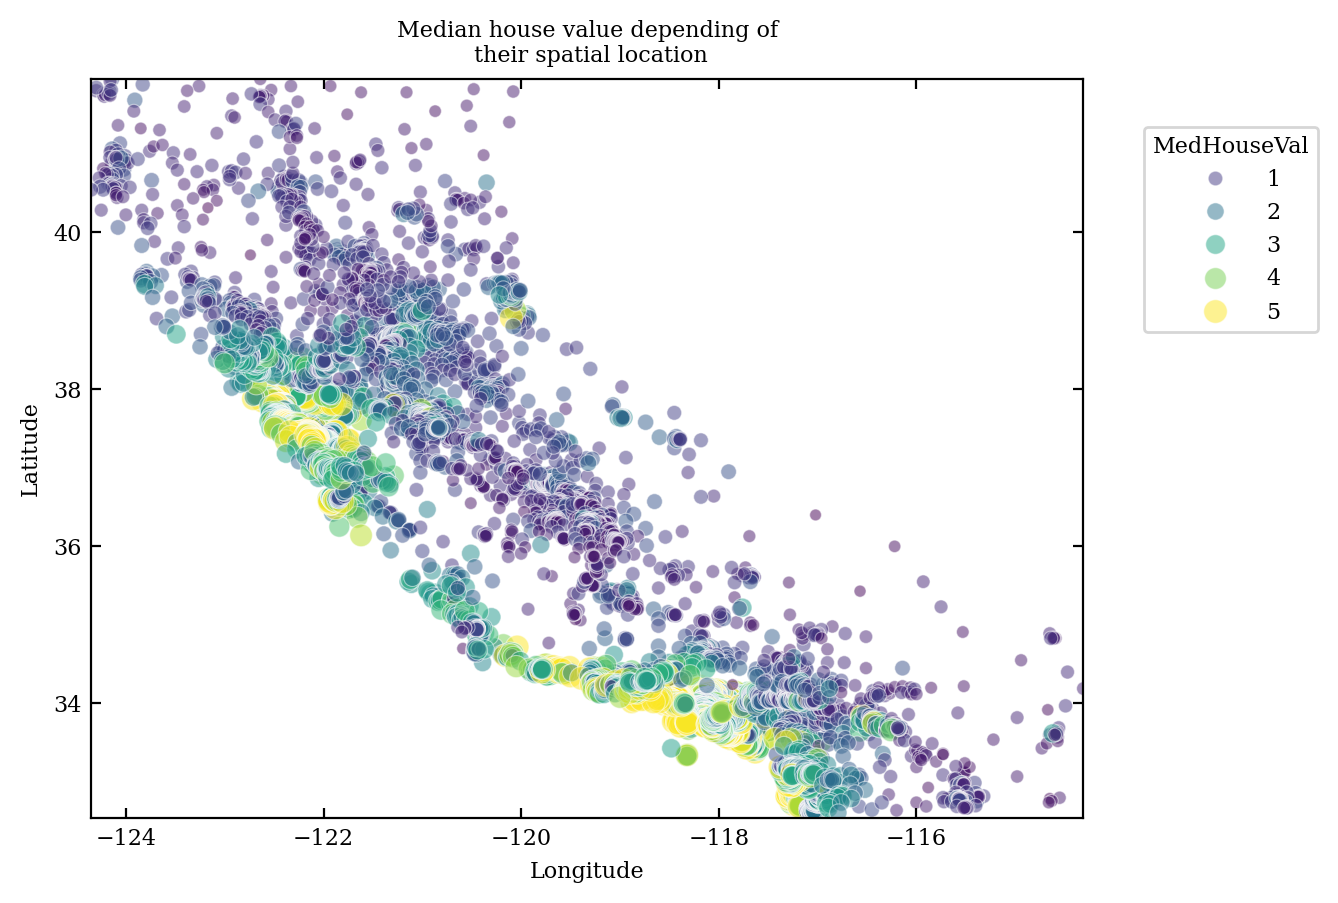

In [29]:
import seaborn as sns

california_housing = fetch_california_housing(as_frame=True)
sns.scatterplot(
    data=california_housing.frame,
    x="Longitude",
    y="Latitude",
    size="MedHouseVal",
    hue="MedHouseVal",
    palette="viridis",
    alpha=0.5,
)
plt.legend(title="MedHouseVal", bbox_to_anchor=(1.05, 0.95), loc="upper left")
_ = plt.title("Median house value depending of\n their spatial location")

(which if you're a tiny bint familiar with California makes perfect sense. The two yellow region are the Bay Area in the north and Los Angeles in the South. I suspect the yellow dot is Lake Tahoe.)

Start by looking at just how the local median income predicts the value of a house.

In [30]:
RMindex = np.squeeze(np.argwhere(np.array(housing.feature_names)=="MedInc"))
print(RMindex)

X_RM = housing.data[:,RMindex][:,None]
y = housing.target

from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_RM, y)
print(reg.coef_, reg.intercept_)

0
[0.41793849] 0.45085576703267827


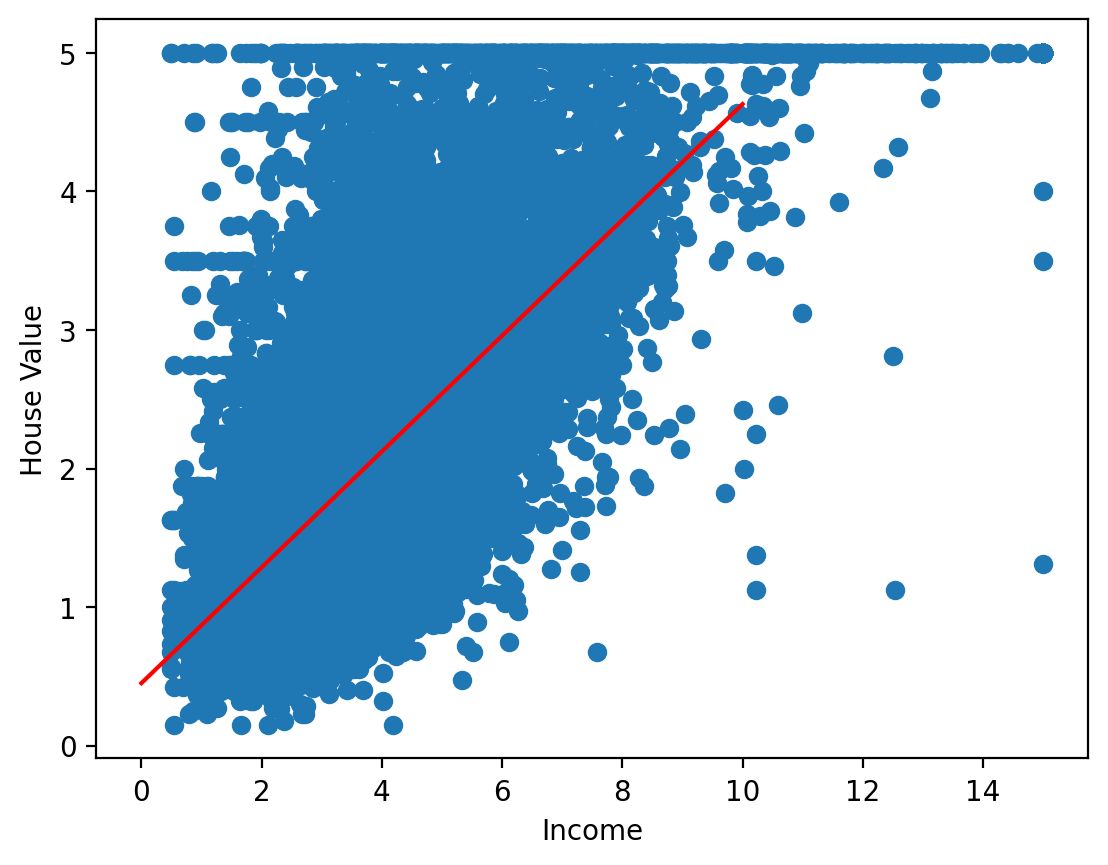

In [11]:
import matplotlib.pyplot as plt
plt.scatter(X_RM,y)
plt.xlabel("Income")
plt.ylabel("House Value")

Xgrid = np.linspace(0,10,9)
ypred = reg.intercept_ + Xgrid*reg.coef_[0]
plt.plot(Xgrid,ypred, c='r')
#plt.xlim(3.5,9)
#plt.ylim(0,5)
plt.show()

- Now use **all attributes**, first with `LinearRegression`.  
- Then with `LinearRegression` again, but with the data scaled using `StandardScaler` from `sklearn.preprocessing` (since the features are very heterogeneous, i.e. they vary over different ranges and scales). 
- Then fit the scaled data agin with LASSO to see which features aren't that important. Experiment with the $\alpha$ value. 
- We'll plot the coefficients of each.

In [31]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

X = housing.data
y = housing.target

scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)

linreg = LinearRegression().fit(X,y)
linreg_scaled = LinearRegression().fit(Xscaled,y)
lasso_scaled = Lasso(alpha=0.1).fit(Xscaled,y)

print("Just linear regression\n", linreg.coef_, linreg.intercept_)
print("\nScaled\n", linreg_scaled.coef_, linreg_scaled.intercept_)
print("\nRegularized\n", lasso_scaled.coef_, lasso_scaled.intercept_)

Just linear regression
 [ 4.36693293e-01  9.43577803e-03 -1.07322041e-01  6.45065694e-01
 -3.97638942e-06 -3.78654265e-03 -4.21314378e-01 -4.34513755e-01] -36.941920207184474

Scaled
 [ 0.8296193   0.11875165 -0.26552688  0.30569623 -0.004503   -0.03932627
 -0.89988565 -0.870541  ] 2.0685581690891386

Regularized
 [ 0.70571337  0.10601099 -0.         -0.         -0.         -0.
 -0.01121267 -0.        ] 2.068558169089147


/var/folders/zv/8t9z941x3q1gmp080mdw8k_h0000gn/T/ipykernel_20108/1814838736.py:8: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(311 + i)


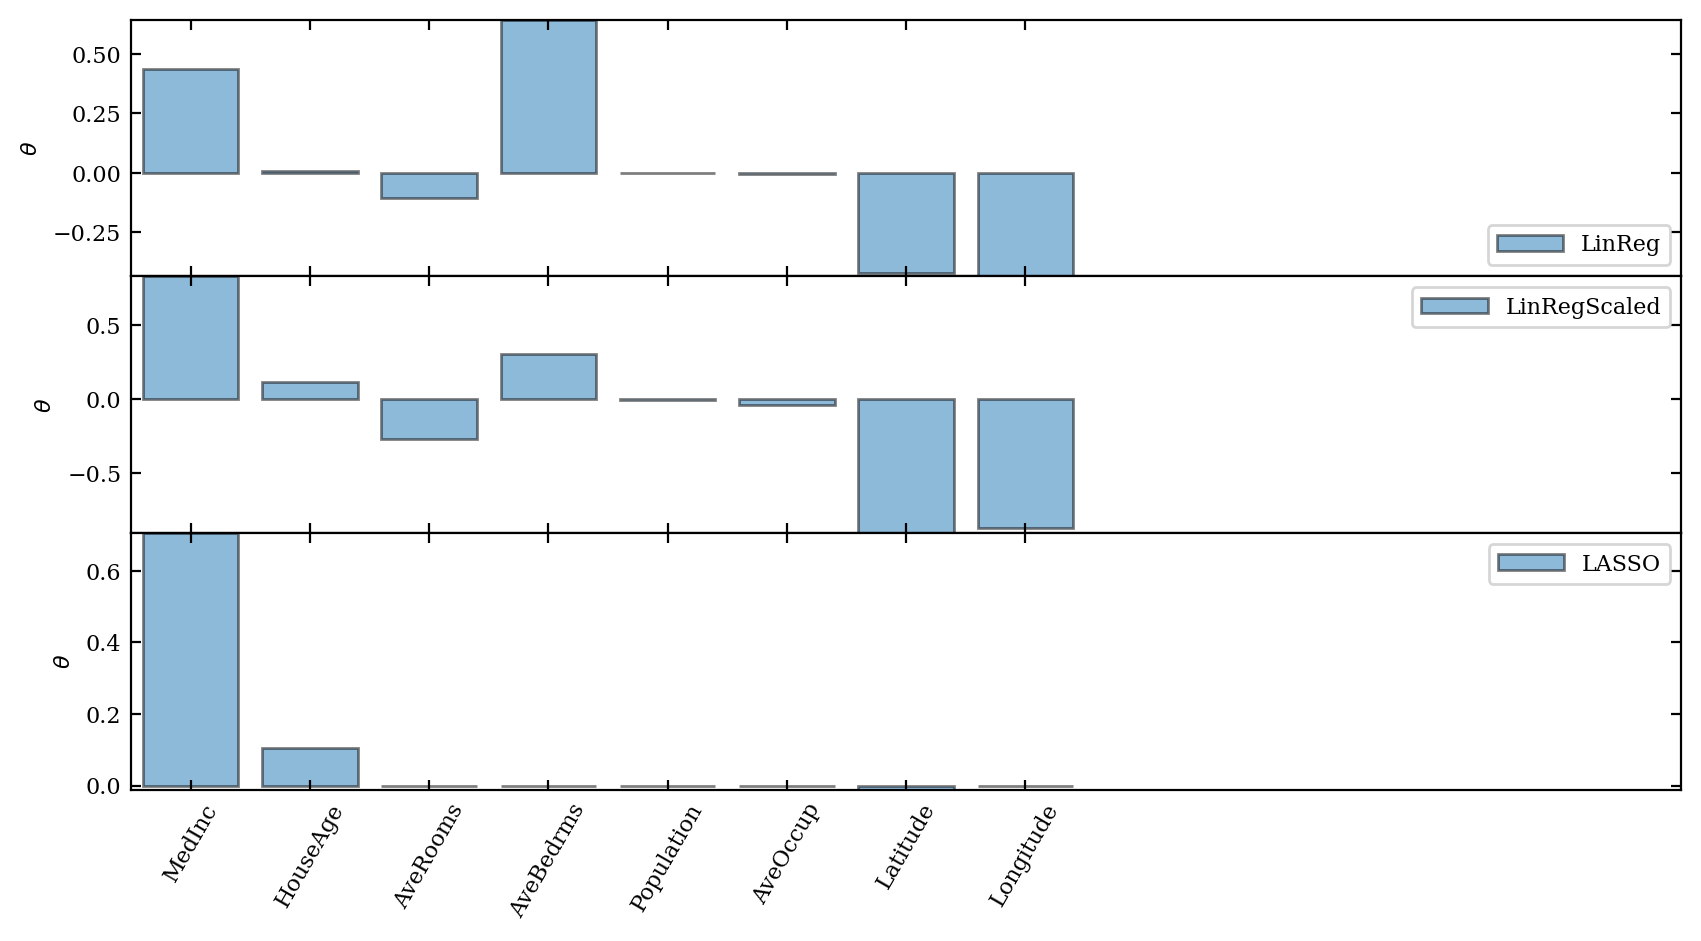

In [32]:
fig, ax = plt.subplots(figsize=(10, 5)) 
plt.subplots_adjust(hspace=0.001)

x_pos = np.arange(len(housing.feature_names))

for i in range(3):
    # plot theta
    ax = plt.subplot(311 + i)
    ax.set_ylabel(r'$\theta$')

    ax.set_xticks(x_pos)
    if i == 2:
        ax.set_xticklabels(housing.feature_names, 
                           rotation=60)     
    else: 
        ax.set_xticklabels([])
    
    ax.set_xlim(-0.5, 12.5)
 
    if i == 0:
        ax.bar(x_pos, linreg.coef_, 
               alpha=0.5, label="LinReg")
        plt.legend(loc=4)
        
    elif i == 1:
        ax.bar(x_pos, linreg_scaled.coef_, 
               alpha=0.5, label="LinRegScaled")
        plt.legend(loc=1)
        
    elif i == 2:
        ax.bar(x_pos, lasso_scaled.coef_, 
               alpha=0.5, label="LASSO")
        plt.legend();

Note that AveBedrms had a large coefficient but isn't particularly relevant.  So, should probably scale the data first. 

Which attribute coefficients are driven toward zero the most, and thus which attributes don't matter in determining the housing prices?

Let's try `LassoCV` below:

In [33]:
from sklearn.linear_model import LassoCV

lasso_scaled_cv = LassoCV(cv=5).fit(Xscaled,y)

print(lasso_scaled_cv.coef_, lasso_scaled_cv.intercept_)
print(lasso_scaled_cv.alpha_)

[ 0.81616436  0.1211406  -0.23007984  0.27029251 -0.0009902  -0.0369377
 -0.8718173  -0.84084069] 2.068558169089139
0.0025999572889688115


For a quick summary of regularization tecniques, [this blog post](https://towardsdatascience.com/what-is-regularization-and-how-do-i-use-it-f7008b5a68c6) is great.

---

## Gaussian Process Regression (GPR) <a class="anchor" id="three"></a>

A powerful class of regression algorithms is **Gaussian Process Regression**; despite its name, GPR is widely applicable to data that are not generated by a Gaussian process, and can give very general and flexible models that are more data-driven than other techniques. It's become quite a hot topic in astrostatistics, and I use GPR a ton. Not only is it **an excellent data-driven interpolation technique, but it also gives you a measure of the interpolation uncertainty.** 



### Example from my own research in gravitational-waves.
We have applied GPR very succesfully to interpolate banks of stellar-physics simulations, which are then used as priors in a Bayesian data analysis. See [Taylor and Gerosa (2018)](https://ui.adsabs.harvard.edu/abs/2018PhRvD..98h3017T/abstract), [Wong and Gerosa (2019)](https://ui.adsabs.harvard.edu/abs/2019PhRvD.100h3015W/abstract).

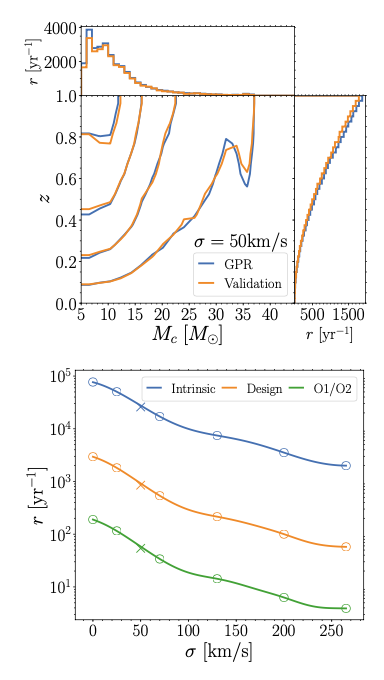

Here we fit the distributon of chirp mass $M_c$, redshift $z$ and detection rate $r$ of the black holes resulting from binary stellar evolution as a function of the linear momentum emitted during the supernova explosion $\sigma$. 

We've also used to to predict the properties of a black holes that is left behind following a black-hole merger ([Varma, Gerosa et al 2019](https://ui.adsabs.harvard.edu/abs/2019PhRvL.122a1101V/abstract), [Boschini, Gerosa et al 2024](https://ui.adsabs.harvard.edu/abs/2023PhRvD.108h4015B/abstract)). For instance this is the post-merger mass. It was a interesting/challenging regression problem because we had training data at the edges of the parameter space and nothing in between, which is very rare! This is because for equal-mass binaries (low $q$) people can do simulations, while for extremely unequal masses (large $q$) there's an analytic limit.

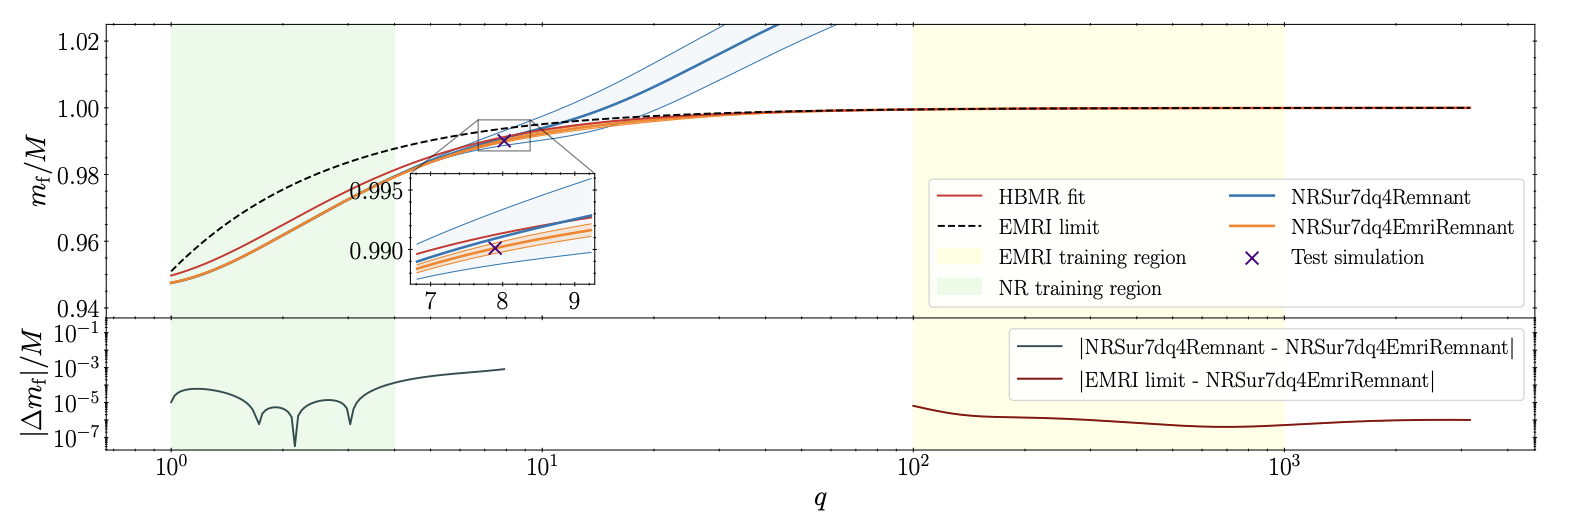

(this was Matteo Boschini's MSc thesis project with me).

For more GPR by us see [Pacilio et al 2024](https://arxiv.org/abs/2408.05276) and [Nobili et al 2025](https://arxiv.org/abs/2504.17021), this time for black-hole ringdowns.

The big text for GPR is **[Rasmussen and Williams "Gaussian Processes for Machine Learning" (2005)](http://www.gaussianprocess.org/gpml/)**. 

> *A **[Gaussian Process](https://en.wikipedia.org/wiki/Gaussian_process) (GP)** is a collection of random variables in a parameter space for which any subset can be defined by a joint Gaussian distribution.*


Here is the code that produces Figure 8.10 in the Ivezic textbook. 

best-fit theta = 0.5994756327330251


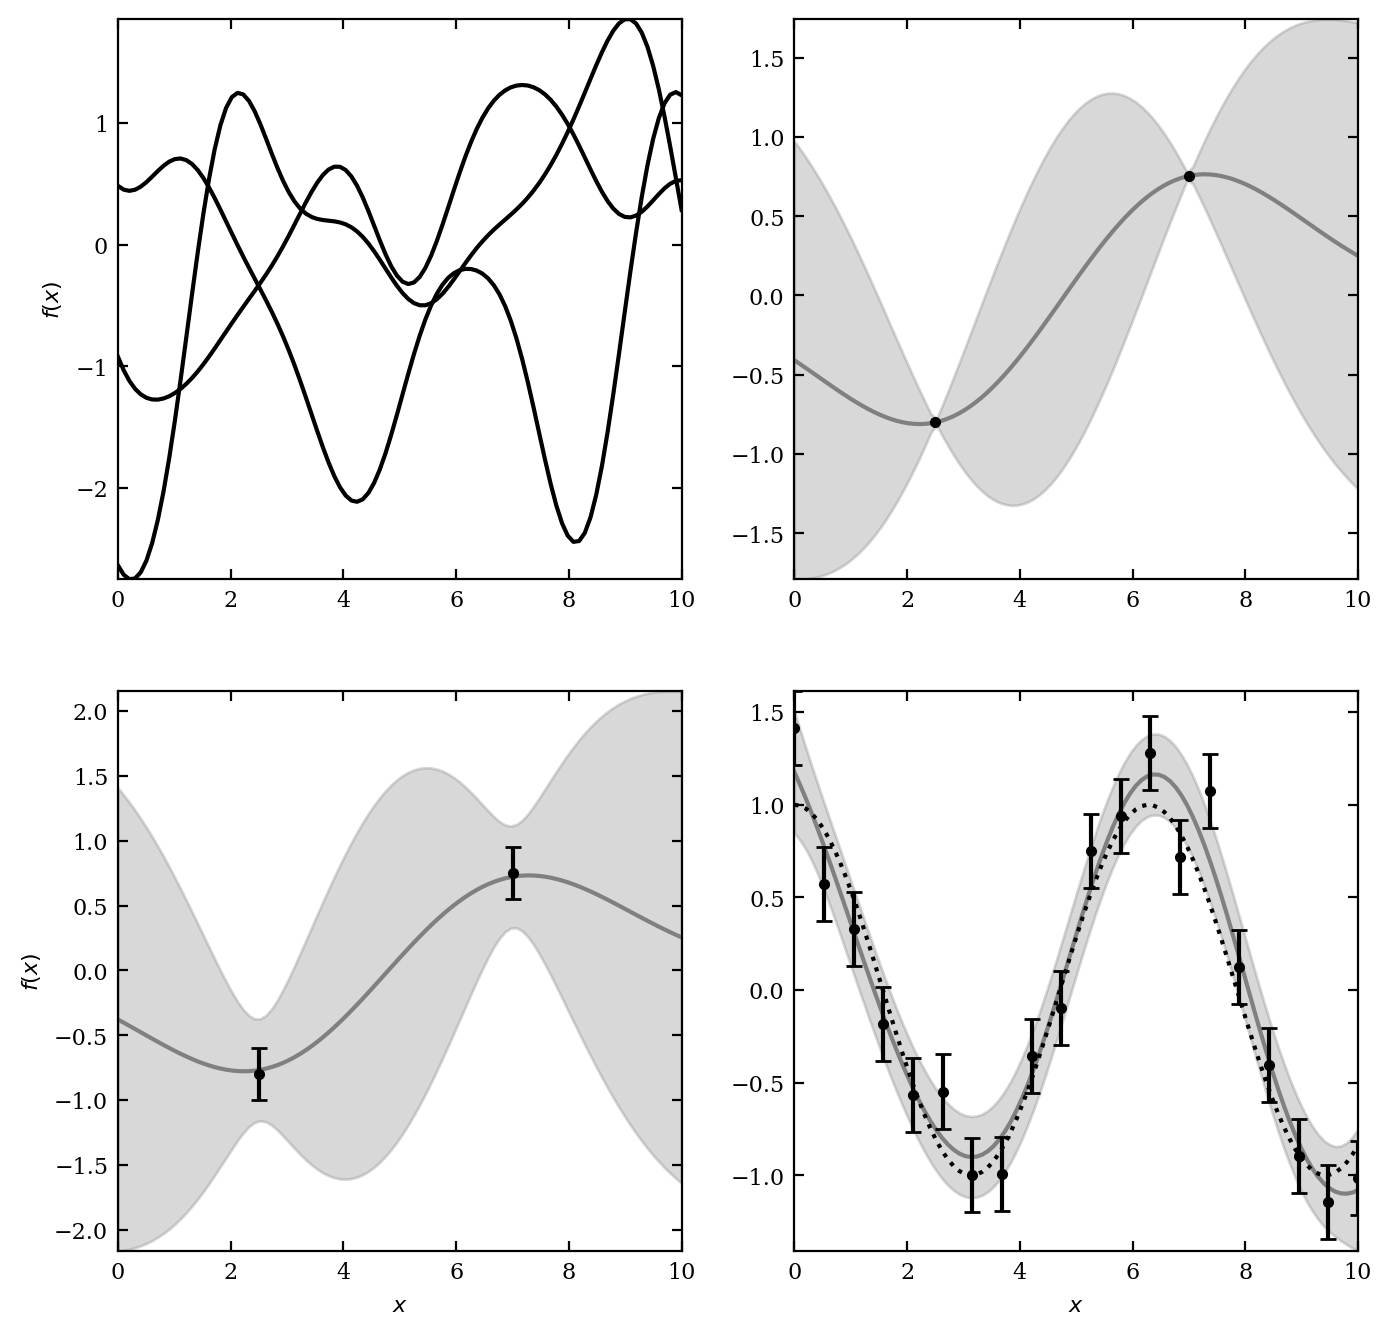

In [45]:
# Ivezic v2, Figure 8.10
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
from scipy.optimize import fmin_cobyla

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)


#------------------------------------------------------------
# define a squared exponential covariance function
def squared_exponential(x1, x2, h):
    return np.exp(-0.5 * (x1 - x2) ** 2 / h ** 2)

#------------------------------------------------------------
# draw samples from the unconstrained covariance
np.random.seed(1)
x = np.linspace(0, 10, 100) #This sets the number of Gaussians
h = 1.0  #This is the Bandwidth

mu = np.zeros(len(x))
C = squared_exponential(x, x[:, None], h)
draws = np.random.multivariate_normal(mu, C, 3)

#------------------------------------------------------------
# Constrain the mean and covariance with two points
x1 = np.array([2.5, 7])
y1 = np.cos(x1)
kernel1 = kernels.RBF(1/0.5, (1/0.5, 1/0.5))
gp1 = GaussianProcessRegressor(kernel=kernel1, 
                               random_state=0, normalize_y=True,optimizer=None)
gp1.fit(x1[:, None], y1)
f1, f1_err = gp1.predict(x[:, None], 
                         return_std=True)

#------------------------------------------------------------
# Constrain the mean and covariance with two noisy points
#  scikit-learn gaussian process uses nomenclature from the geophysics
#  community, where a "nugget (alpha parameter)" can be specified.
#  The diagonal of the assumed covariance matrix is multiplied by the nugget.
#  This is how the error on inputs is incorporated into the calculation.
dy2 = 0.2
kernel2 = kernels.RBF(1/0.5, (1/0.5, 1/0.5))
gp2 = GaussianProcessRegressor(kernel=kernel2,
                               #alpha=(dy2 / y1) ** 2, 
                               alpha=dy2**2,
                               random_state=0,optimizer=None)
gp2.fit(x1[:, None], y1)
f2, f2_err = gp2.predict(x[:, None], 
                         return_std=True)


#------------------------------------------------------------
# Constrain the mean and covariance with many noisy points
x3 = np.linspace(0, 10, 20)
y3 = np.cos(x3)
dy3 = 0.2
y3 = np.random.normal(y3, dy3)

kernel3 = kernels.RBF(0.5, (0.01, 10.0))
gp3 = GaussianProcessRegressor(kernel=kernel3,
                               #alpha=(dy3 / y3) ** 2, 
                               alpha=dy3**2,
                               random_state=0)
gp3.fit(x3[:, None], y3)
f3, f3_err = gp3.predict(x[:, None], 
                         return_std=True)

# we have fit for the `h` parameter: print the result here:
print("best-fit theta =", gp3.kernel_.theta[0])


#------------------------------------------------------------
# Plot the diagrams
fig = plt.figure(figsize=(8, 8))


# first: plot a selection of unconstrained functions
ax = fig.add_subplot(221)
ax.plot(x, draws.T, '-k')
ax.set_ylabel('$f(x)$')

# second: plot a constrained function
ax = fig.add_subplot(222)
ax.plot(x, f1, '-', color='gray')
ax.fill_between(x, f1 - 2 * f1_err, f1 + 2 * f1_err, 
                color='gray', alpha=0.3)
ax.plot(x1, y1, '.k', ms=6)


# third: plot a constrained function with errors
ax = fig.add_subplot(223)
ax.plot(x, f2, '-', color='gray')
ax.fill_between(x, f2 - 2 * f2_err, f2 + 2 * f2_err, 
                color='gray', alpha=0.3)
ax.errorbar(x1, y1, dy2, fmt='.k', ms=6)

ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')

# third: plot a more constrained function with errors
ax = fig.add_subplot(224)
ax.plot(x, f3, '-', color='gray')
ax.fill_between(x, f3 - 2 * f3_err, f3 + 2 * f3_err, 
                color='gray', alpha=0.3)
ax.errorbar(x3, y3, dy3, fmt='.k', ms=6)

ax.plot(x, np.cos(x), ':k')

ax.set_xlabel('$x$')

for ax in fig.axes:
    ax.set_xlim(0, 10)

plt.show()

In the **top-left panel**, we have drawn some random distributions from a Gaussian Basis. Specifically, we set zero mean and a covariance given by 

$${\rm Cov}(x_1, x_2; h) = \exp\left(\frac{-(x_1 - x_2)^2}{2 h^2}\right).$$

where $h$ is a bandwidth (this is done explicitely by creating the $N \times N$ covariance matrix $C$ and drawing $N$ correlated Gaussian random variables with mean 0 and covariance $C$; see code.)

For a given bandwidth we can obviously define an infinite set of such functions. ***NOTE: This is only one of many different types of covariance function we could assume to interpolate the data.*** A variety of others are shown [here](https://www.cs.toronto.edu/~duvenaud/cookbook/). 



See what happens if you make the number of Gaussians much smaller or much bigger, or if you change the bandwidth.

Then in the **top-right panel**, we constrain these functions by selecting those that pass though a given set of points using the posterior:

$$p(f_j | \{x_i, y_i, \sigma_i\}, x_j^\ast).$$

The **bottom panels** show the result for the same points with error bars (*bottom left*) and 20 noisy points drawn from $y=\cos(x)$ (*bottom right*). You can perhaps see how this might be useful-- flexible, data-driven interpolation with a measure of interpolation uncertainty!

For GP regression we want to estimate the value and variance of a new set of points given an input data set. **This is equivalent to averaging over all functions that pass through our input data**.

We compute the covariance matrix of all observed data and the new set of points that we want to predict:

$$  K = \begin{pmatrix}
    K_{11} & K_{12} \\
    K_{12}^T & K_{22}
  \end{pmatrix},
$$

where 
- $K_{11}$ is the covariance between the input points $x_i$ with observational errors $\sigma_i^2$ added in quadrature to the diagonal, 
- $K_{12}$ is the cross-covariance between the input points $x_i$ and the unknown points $x^\ast_j$,
- $K_{22}$ is the covariance between the unknown points $x_j^\ast$.  

For observed vectors $\vec{x}$ and $\vec{y}$, and a vector of unknown points $\vec{x}^\ast$, it can be shown that the posterior is given by (see the Rasmussen & Williams text above for a detailed proof)

$$  p(f_j | \{x_i, y_i, \sigma_i\}, x_j^\ast) = \mathcal{N}(\vec{\mu}, \Sigma) $$

where

$$
\begin{eqnarray}
  \vec{\mu} &=& K_{12} K_{11}^{-1} \vec{y}, \\
  \Sigma &=& K_{22} - K_{12}^TK_{11}^{-1}K_{12}
\end{eqnarray}
$$

$\mu_j$ gives the expected value $\bar{f}^\ast_j$ of the predicted result, and $\Sigma_{jk}$ gives the error covariance between any two unknown points (which measures the prediction uncertainty).

**This is key: it gives the mean AND uncertainty of a predicted point.**

Note that the physics of the underlying process enters through the assumed form of the covariance function, which has a variety of choices-- again see the [Kernel Cookbook](https://www.cs.toronto.edu/~duvenaud/cookbook/). 

The Scikit-Learn [`GaussianProcess`](https://scikit-learn.org/stable/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html#sklearn.gaussian_process.GaussianProcessRegressor) implementation looks like:

In [39]:
from sklearn.gaussian_process import GaussianProcessRegressor

X = np.random.random((100,2))
y = np.sin(10*X[:,0] + X[:,1])
gp = GaussianProcessRegressor()
gp.fit(X,y)
y_pred, dy_pred = gp.predict(X, return_std=True)
print(y_pred, dy_pred)

[ 0.68366614  0.5011659  -0.35953486  1.03548357 -0.42083378  1.01371533
  0.74337885  0.75505781 -0.97548946 -0.46096907  0.63955323  0.44010141
  0.96169744 -0.27369161  0.7417642  -0.97743062  0.93314464 -0.3291255
  0.87098739 -0.08375727 -0.76030672  0.14810586  0.15478119 -0.54790404
 -0.65636122  0.83942944 -0.1905015  -0.961214    0.14471319  0.38553748
  1.0011448   0.66230105 -0.90993986 -0.01153512  0.21453124  0.99105161
 -0.73212484  1.01383781  0.86697382 -0.83421549  0.45106399  0.37422854
 -0.9064841  -0.62377673  0.93802875  0.15164369 -0.23039739  0.97937474
 -0.3544459  -0.55224216 -0.87626913 -0.38313441  0.8682436   0.22025609
  1.00768045 -0.71703722  0.97056648  0.84943217 -0.86150853  0.03052115
 -0.91806643  0.9462287   0.52679881 -0.28304522  0.99897134 -0.48059859
  1.01682287 -0.96310996  0.4285146  -0.01123539  0.52221616 -0.95249021
  0.75415592  0.27885696  0.55262202 -0.60476001 -0.96333456  1.0311334
  0.44018982 -0.9084809  -0.42849955 -0.01796771 -0.7

Below we'll see what GPR does for the supernova example that we used last time. What is great is that not only do you get a fit, you get errors and can tell where the fit is good and where it is poor. Clearly, as expected, the prediction gets successively poor as we move beyond the range of the training data.

## [Optional, not examinable] Non-linear Regression <a class="anchor" id="two"></a>

Up to now we have been mostly fitting ***linear models***, i.e. where the model depends linearly on the regression coefficients. Non-linear regression is complicated... Some very superficial notes here:

Often we can make our non-linear data linear (e.g., if your $y$ values increase exponentially with $x$, by taking the log), but that has its own set of complications (e.g., asymmetric error bars). So we should also consider **non-linear regression, i.e., where the model depends non-linearly on the regression parameters.** 

If we know the theoretical form of the model, then one option is to use MCMC techniques to sample the parameter space and find the optimal model parameters. We've seen that in detail.

An alternate approach is to use the **Levenberg-Marquardt (LM) algorithm** to optimize the maximum likelihood estimation. **[Numerical Recipes](http://numerical.recipes/)** is an excellent resource for more information about LM. I can't really emphasize enough how ubiquitous LM is, so you really should have a look at how it works.

For now let's leave it as these few words of explanation (with links for further study).
> *LM searches through a combination of [gradient descent](https://en.wikipedia.org/wiki/Gradient_descent) and [Gauss-Newton](https://en.wikipedia.org/wiki/Gauss%E2%80%93Newton_algorithm) optimization.* 

If we can **express our regression function as a Taylor series expansion** then, to first order, we can write

$$f(x_i|\theta) = f(x_i|\theta_0) + J d\theta.$$

Here $\theta_0$ is an initial guess for the regression parameters, $J$ is the Jacobian about this point ( $J=\partial f(x_i|\theta)/ \partial\theta$ ), and $d\theta$ is a perturbation in the regression parameters. 

LM minimizes the sum-of-square errors,

$$\sum_i [y_i- f(x_i|\theta_0) - J_i d\theta]^2,$$

for a perturbation $d\theta$. This minimization results in an iterative update relation for
$d\theta$ given by

$$(J^TC^{-1}J + \lambda\ {\rm diag}(J^TC^{-1}J) )\,d\theta = J^TC^{-1}(Y-f(X|\theta)),$$

where **$\lambda$ term acts as a damping parameter**. 
- If $\lambda$ is small, then the relation approximates a Gauss-Newton method (i.e., it minimizes the parameters assuming the function is locally quadratic). 
- If $\lambda$ is large the perturbation $d\theta$ follows the direction of steepest descent. 
- The diag$(J^TC^{-1}J)$ term ensures that the update of $d\theta$ is largest along directions where the gradient is smallest (which improves convergence).

This is an iterative process which ceases when the change in likelihood values reaches a predetermined limit. Don't worry if "gradient descent" doesn't ring any bells. We are going to talk about it again when we get to artificial neural networks.

In SciPy, both **[`scipy.optimize.leastsq`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.leastsq.html)**  and **[`scipy.optimize_curve_fit`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)** implement the LM algorithm. You've probably used LM a lot already without noticing it!


Here is an example call to estimate the first 6 terms of the Taylor series for $y=\sin x$.

In [34]:
from scipy import optimize

x = np.linspace(-3,3,100) # 100 values between -3 and 3

def taylor_err(a, x, f):
    p = np.arange(len(a))[:, None]
    return f(x) - np.dot(a, x**p)

a_start = np.zeros(6) # starting guess
a_best, flat = optimize.leastsq(taylor_err, a_start, 
                                args=(x, np.sin))

In [35]:
print(a_best) #Print coefficients of the Taylor series exapansion.  Do they make sense?

[-3.72507836e-17  9.90094836e-01  1.61910222e-16 -1.56677082e-01
 -3.36219637e-17  5.80542809e-03]


## [Optional, not examinable] Uncertainties All Round <a class="anchor" id="four"></a>

What about real-world applications, where the **independent variable, $x$, (usually) is not free from any uncertainty**? Imagine the "true" relation,

$$ y^*_i=\theta_0 + \theta_1x^*_{i}. $$

Now we make measurements in $x$, and $y$ which are noisy (Gaussian noise)

$$
x_i = x^*_i + \delta_i,\\
y_i = y^* + \epsilon_i,
$$

Solving for $y$ we get
$$
      \hat{y}_i=  \theta_0 + \theta_1 (x_i - \delta_i) +\epsilon_i.
$$

Thus $\hat{y}$ depends on the noise in $x$, such that the uncertainty in $x$ is now part of the regression equation and scales with the regression coefficients. 

This problem is known as **Total Least Squares (TLS)**. In TLS, we build a likelihood that measures the **perpendicular distance of points from a modeled line**, rather than what we have done thus far in ordinary least squares (OLS) which measures only the **vertical distance of $y$ data values from the modeled curve**. Image credit: [here](https://towardsdatascience.com/total-least-squares-in-comparison-with-ols-and-odr-f050ffc1a86a).

![](https://miro.medium.com/max/854/1*illoIj5LRD3NrQ69iV30kw.png)

How can we account for the measurement uncertainties in both the independent and dependent variables? Assuming they are Gaussian, the total data covariance matrix is

$$ \Sigma_i = \left[
\begin{array}{cc}
\sigma_{x_i}^2 & \sigma_{xy_i} \\
\sigma_{xy_i} & \sigma_{y_i}^2
\end{array}
\right].
$$

We'll consider straight-line regression. **It will help us to think of our line geometrically, where we define it in terms of its normal vector**:

$$ {\bf n} = \left [
\begin{array}{c}
-\sin \alpha\\
\cos \alpha\\
\end{array}
\right ] 
$$

with $\theta_1 = \arctan(\alpha)$ and $\alpha$ is the angle between the line and the $x$-axis. 

The covariance matrix projects onto this space as

$$ S_i^2 = {\bf n}^T \Sigma_i {\bf n} $$

and the  distance between a point and the line is

$$\Delta_i = {\bf n}^T z_i - \theta_0\ \cos \alpha, $$
  
where $z_i$ represents the data point $(x_i,y_i)$. You may need to think and sketch out the latter equation. The first part makes sense since it is just projecting the coordinate vector onto the line's normal vector. The second part subtracts off the excess of this projection in case the line is vertically offset from zero-intercept. 

The log-likelihood is then

$$ \ln\mathcal{L} \propto - \sum_i \frac{\Delta_i^2}{2 S_i^2}$$

and we can maximize the likelihood as a brute-force search or through MCMC. 

In the following code cell, data has uncertainties in $x$ and $y$, and a straight line is numerically fit through **Total Least Squares**. The resulting measured parameter uncertainty regions for the intercept and slope are shown in the right panel.


TLS is not the only way to do this. This is a nice blog post with comparisons: https://readmedium.com/total-least-squares-in-comparison-with-ols-and-odr-f050ffc1a86a


Optimization terminated successfully.
         Current function value: 55.711167
         Iterations: 88
         Function evaluations: 164


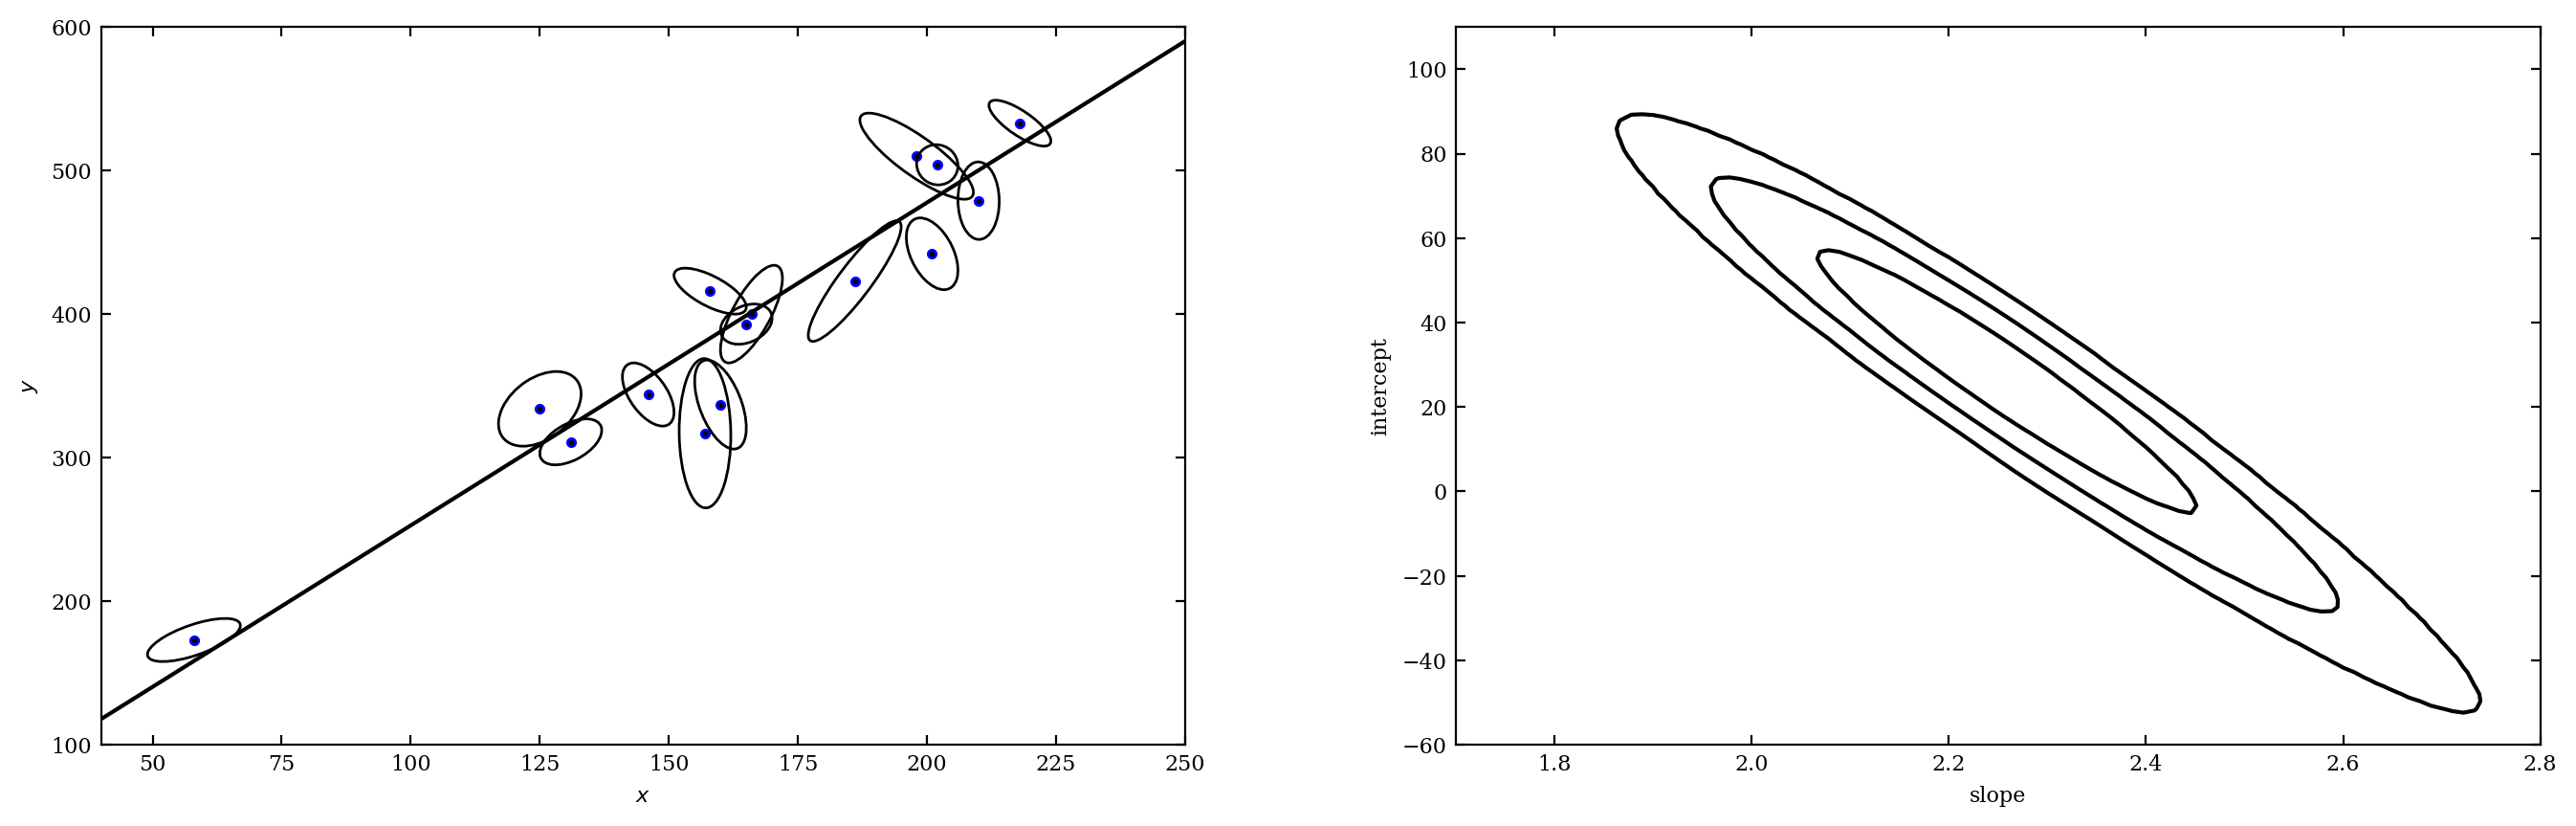

In [40]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from scipy import optimize
from matplotlib.patches import Ellipse

from astroML.linear_model import TLS_logL
from astroML.plotting.mcmc import convert_to_stdev
from astroML.datasets import fetch_hogg2010test

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)


#------------------------------------------------------------
# Define some convenience functions

# translate between typical slope-intercept representation,
# and the normal vector representation
def get_m_b(beta):
    b = np.dot(beta, beta) / beta[1]
    m = -beta[0] / beta[1]
    return m, b


def get_beta(m, b):
    denom = (1 + m * m)
    return np.array([-b * m / denom, b / denom])


# compute the ellipse pricipal axes and rotation from covariance
def get_principal(sigma_x, sigma_y, rho_xy):
    sigma_xy2 = rho_xy * sigma_x * sigma_y

    alpha = 0.5 * np.arctan2(2 * sigma_xy2,
                             (sigma_x ** 2 - sigma_y ** 2))
    tmp1 = 0.5 * (sigma_x ** 2 + sigma_y ** 2)
    tmp2 = np.sqrt(0.25 * (sigma_x ** 2 - sigma_y ** 2) ** 2 + sigma_xy2 ** 2)

    return np.sqrt(tmp1 + tmp2), np.sqrt(tmp1 - tmp2), alpha


# plot ellipses
def plot_ellipses(x, y, sigma_x, sigma_y, 
                  rho_xy, factor=2, ax=None):
    if ax is None:
        ax = plt.gca()

    sigma1, sigma2, alpha = get_principal(sigma_x, 
                                          sigma_y, 
                                          rho_xy)

    for i in range(len(x)):
        ax.add_patch(Ellipse((x[i], y[i]),
                     width=factor * sigma1[i],
                     height=factor * sigma2[i],
                     angle=alpha[i] * 180. / np.pi,
                     fc='none', ec='k'))

#------------------------------------------------------------
# We'll use the data from table 1 of Hogg et al. 2010
data = fetch_hogg2010test()
data = data[5:]  # no outliers
x = data['x']
y = data['y']
sigma_x = data['sigma_x']
sigma_y = data['sigma_y']
rho_xy = data['rho_xy']

#------------------------------------------------------------
# Find best-fit parameters
X = np.vstack((x, y)).T
dX = np.zeros((len(x), 2, 2))
dX[:, 0, 0] = sigma_x ** 2
dX[:, 1, 1] = sigma_y ** 2
dX[:, 0, 1] = dX[:, 1, 0] = rho_xy * sigma_x * sigma_y

min_func = lambda beta: -TLS_logL(beta, X, dX)
beta_fit = optimize.fmin(min_func,
                         x0=[-1, 1])

#------------------------------------------------------------
# Plot the data and fits
fig = plt.figure(figsize=(15, 5))
fig.subplots_adjust(left=0.1, right=0.95, wspace=0.25,
                    bottom=0.15, top=0.9)

#------------------------------------------------------------
# first let's visualize the data
ax = fig.add_subplot(121)
ax.scatter(x, y, c='k', s=9)
plot_ellipses(x, y, sigma_x, sigma_y, rho_xy, ax=ax)

#------------------------------------------------------------
# plot the best-fit line
m_fit, b_fit = get_m_b(beta_fit)
x_fit = np.linspace(0, 300, 10)
ax.plot(x_fit, m_fit * x_fit + b_fit, '-k')

ax.set_xlim(40, 250)
ax.set_ylim(100, 600)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

#------------------------------------------------------------
# plot the likelihood contour in m, b
ax = fig.add_subplot(122)
m = np.linspace(1.7, 2.8, 100)
b = np.linspace(-60, 110, 100)
logL = np.zeros((len(m), len(b)))

for i in range(len(m)):
    for j in range(len(b)):
        logL[i, j] = TLS_logL(get_beta(m[i], b[j]), X, dX)

ax.contour(m, b, convert_to_stdev(logL.T),
           levels=(0.683, 0.955, 0.997),
           colors='k')
ax.set_xlabel('slope')
ax.set_ylabel('intercept')
ax.set_xlim(1.7, 2.8)
ax.set_ylim(-60, 110)

plt.show();

## Time to get your hands dirty! Supernova distances and redshifts (part 2 - 3)

*(exam guidelines available [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/exams.md))*


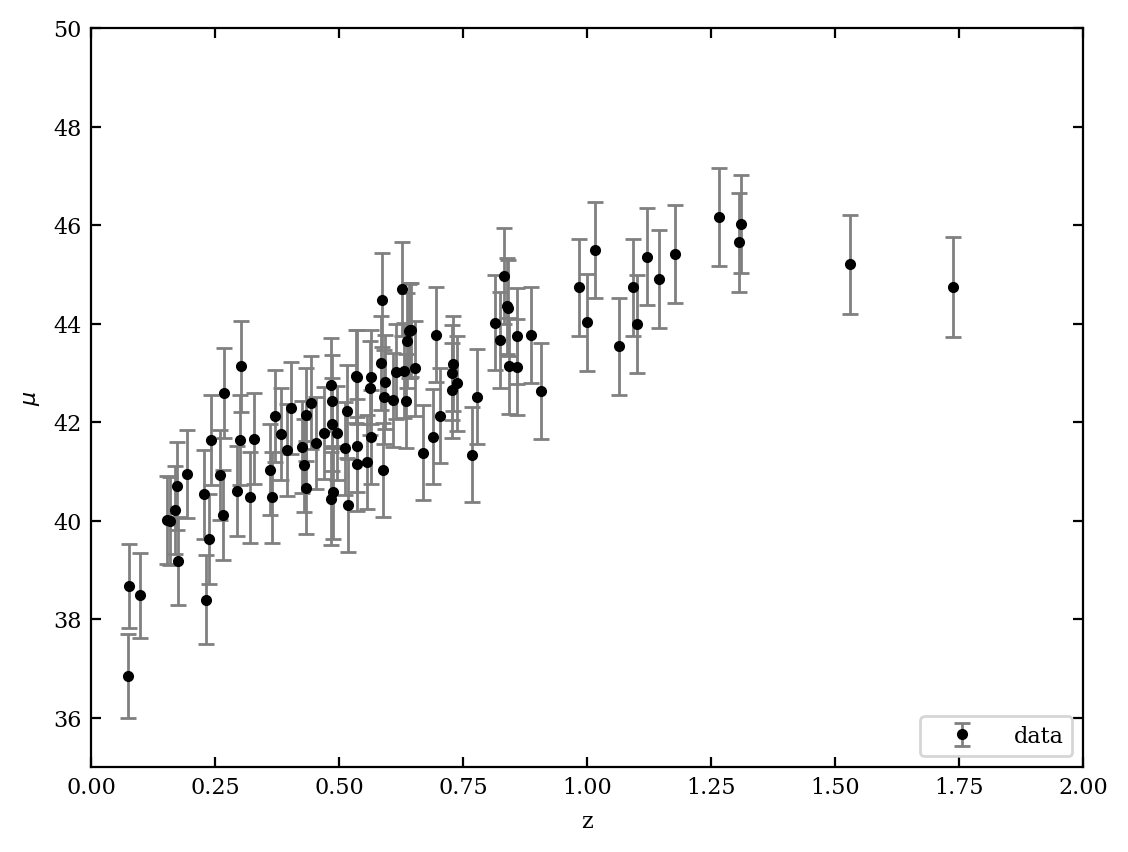

In [20]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

### Part 2 (start in class)

First let's fit our supernova synthetic data from last time using GPR.

- The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
- Radial-basis function kernel (aka squared-exponential kernel) is a standard choice in the GPR world.
- But check out what's available in the `kernels` submodule of [sklearn.gaussian_process](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.gaussian_process)
- Plot the expectation value of the fit as well as the resulting 1-$\sigma$ and 2-$\sigma$ contours.
- Interpret the results.

*Note*. To start with, feel free to tweak the hyperparameters manually. But, of course, a publication-quality result will require a cross-validation analysis.

The European Space Agency is considering new cosmology-related space mission. They ask you to figure out what science you can do with 10 times more measurement compared to what you have right now. That is: you want to clone your data. We've seen this earlier in the class, but now we can do much much better.
- Think about the pdf of these data in $z$.
- Using your GPR fit, generate a set of $\mu$ measurements that respects the statistical properties of the data you were given. 

### Part 3 (for the exam)

*(I know this assignment is longer and more convoluted, but we're getting towards the end of the class and it's important to draw connections between the different things we've done)*

We now have a suite of **data-driven** predictive models for our supernova dataset (from polynomials to GPR). That is: we can faithfully predict how a future redshift/distance measurement will look like given the current sample.

This is already great and these kind of tools are immensely useful in a variety of contexts (also involving a lot of money: suppose you want to predict how much a give financial asset will perform on tomorrow's stock market... You  might not really care about expressing the underlying financial model in simple terms, as long as your investments are profitable).

For the case of supernovae, however, we have do have physical theory which is $\Lambda$CDM. We can do a **parametric** fit (and hopehully by now the difference between "parametric" and "data driven" fit is clear in your head)

- First, refresh your cosmology and write down the predicted relationship between the distance module $\mu$ and the redshift $\sigma$. *Hint* I always forget these things, my to-go reference is [Hogg (2010)](https://arxiv.org/abs/astro-ph/9905116). The answer is:

$$\mu = 5 \log \left( \frac{c/H_0} {10 {\rm pc}}(1+z)\int_0^z \frac{dz'}{\sqrt{\Omega_m (1+z^3)+\Omega_\Lambda}} \right) $$

- Assuming a flat Universe,  we have a parametric non-linear model for $\mu(z)$ that depends on two parameters, the Hubble constant $H_0$ and the matter content of the Universe $\Omega_m$
- It's a very non-linear model. Fit it to the data, however you want to do it, using tecniques we've seen throughout the course. Some ideas:
    - Set up a Bayesian framework and use MCMC. 
    - Set up a fully-connected neural network (see end of the class).

- What are the measured value of $H_0$ and $\Omega_m$. What's they errors? Are they correlated?
- How would a model without dark energy (i.e. $\Omega_m=1$) perform? Do these data contain evidence of dark energy? (Hint: this is a model selection problem!)





[My exploration](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/solutions/S18_supernovae2.ipynb)